<h1 style="color: #25a890; font-size: 2.2em; margin-bottom: 5px; font-weight: 700;">Customer Segmentation | Modeling</h1>

<p style="margin: 3px 0; font-size: 1.1em; font-weight: 600;">NOVA IMS <span style="font-weight: 300;">| Machine Learning II</span></p>
<p style="margin: 3px 0; font-size: 0.95em;"><strong">Professors</strong> Fernando Bação & Ivo Bernardo</p>


<br>
<table style="width: 100%; border-collapse: collapse; font-size: 1em;">
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Diogo Gonçalves</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241817)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Gustavo Franco</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241806)</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: 500;">Simão Costa</td>
        <td style="padding: 4px 0; text-align: right; font-family: monospace;">(20241772)</td>
    </tr>


    


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;">Table of Contents</h3>
<div style="font-family: Arial, sans-serif; line-height: 1.8; margin-bottom: 30px; padding-left: 10px;">
    <ol style="margin-top: 0; padding-left: 20px;">
        <li><a href="#library-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Library Imports</a></li>
        <li><a href="#data-imports" style="color: #25a890; text-decoration: none; font-weight: 500;">Data Import</a></li>
        <li><a href="#elbow-silhouette" style="color: #25a890; text-decoration: none; font-weight: 500;">Elbow Method and Silhouette</a></li>
        <li>
            <a href="#models" style="color: #25a890; text-decoration: none; font-weight: 500;">Models</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#kmeans" style="color: #25a890; text-decoration: none;">K-Means</a></li>
                <li><a href="#hierarchical" style="color: #25a890; text-decoration: none;">Hierarchical Clustering</a></li>
                <li><a href="#dbscan" style="color: #25a890; text-decoration: none;">DBSCAN</a></li>
                <li><a href="#hdbscan" style="color: #25a890; text-decoration: none;">HDBSCAN</a></li>
                <li><a href="#meanshift" style="color: #25a890; text-decoration: none;">Mean Shift</a></li>
                <li><a href="#som" style="color: #25a890; text-decoration: none;">Self Organizing Map</a></li>
            </ul>
        </li>
        <li>
            <a href="#visualization" style="color: #25a890; text-decoration: none; font-weight: 500;">Visualization</a>
            <ul style="list-style-type: circle; padding-left: 20px; margin-top: 5px; margin-bottom: 5px;">
                <li><a href="#tsne" style="color: #25a890; text-decoration: none;">T-SNE</a></li>
                <li><a href="#umap" style="color: #25a890; text-decoration: none;">UMAP</a></li>
                <li><a href="#pca" style="color: #25a890; text-decoration: none;">PCA</a></li>
            </ul>
        </li>
        <li><a href="#cluster-profiles" style="color: #25a890; text-decoration: none; font-weight: 500;">Cluster Profiles</a></li>
        <li><a href="#cluster-profiles" style="color: #25a890; text-decoration: none; font-weight: 500;">Export</a></li>
    </ol>
</div>

In [33]:
# !pip install hdbscan minisom umap-learn

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Library Imports</h2>

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import IsolationForest
import hdbscan
from minisom import MiniSom
import umap
import warnings
warnings.filterwarnings('ignore')

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;">Data Import</h2>

In [35]:
X_scaled = pd.read_csv('X_scaled.csv', index_col='customer_id')

In [36]:
pca = PCA(n_components=11, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, index=X_scaled.index)

In [37]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [38]:
iso = IsolationForest(contamination=0.01, random_state=42)
outlier_mask = iso.fit_predict(X_scaled) == 1
X_scaled_clean = X_scaled[outlier_mask]
outlier_mask_pca = iso.fit_predict(X_pca) == 1
X_pca_clean = X_pca[outlier_mask_pca]

print(f"Removed {(~outlier_mask).sum()} outliers, keeping {outlier_mask.sum()} customers")
print(f"Removed {(~outlier_mask_pca).sum()} outliers, keeping {outlier_mask_pca.sum()} customers, from PCA data")

Removed 331 outliers, keeping 32707 customers
Removed 331 outliers, keeping 32707 customers, from PCA data


<p style="color: #25a890; font-size: 0.9em;">Outlier removal was applied using Isolation Forest to ensure stable clustering results.</p>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Elbow Method and Silhouette</h2>

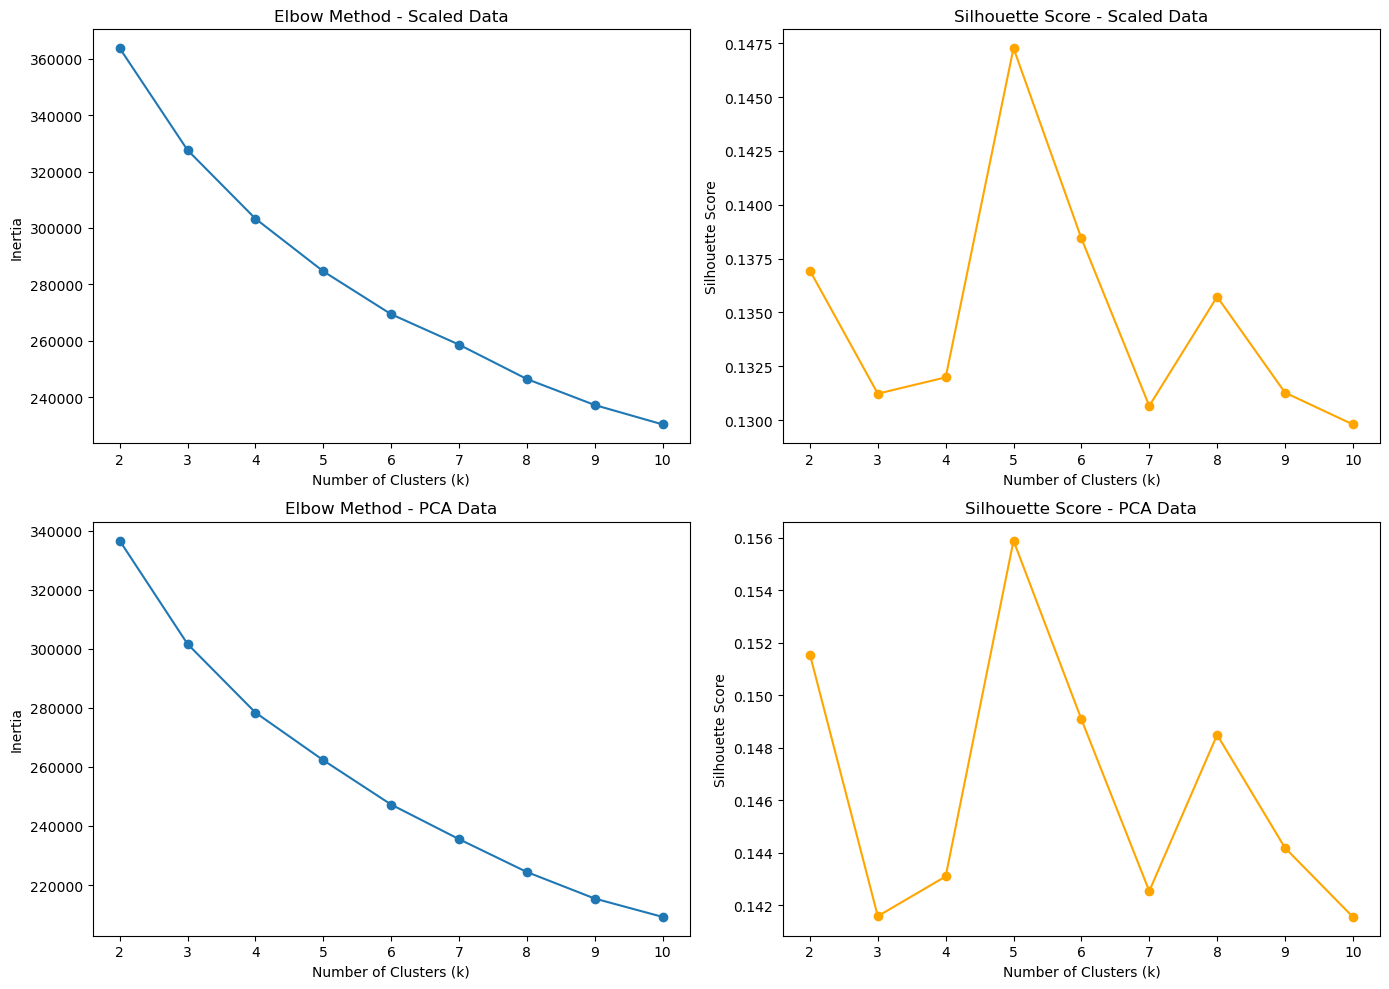

In [39]:
k_range = range(2, 11)
results = {}

for name, X in [('Scaled', X_scaled_clean), ('PCA', X_pca_clean)]:
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))
    results[name] = (inertias, silhouettes)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (name, (inertias, silhouettes)) in enumerate(results.items()):
    axes[row, 0].plot(k_range, inertias, marker='o')
    axes[row, 0].set_title(f'Elbow Method - {name} Data')
    axes[row, 0].set_xlabel('Number of Clusters (k)')
    axes[row, 0].set_ylabel('Inertia')

    axes[row, 1].plot(k_range, silhouettes, marker='o', color='orange')
    axes[row, 1].set_title(f'Silhouette Score - {name} Data')
    axes[row, 1].set_xlabel('Number of Clusters (k)')
    axes[row, 1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">The Elbow Method does not show a clear inflection point, while the Silhouette Score peaks at k=5, supporting the choice of 5 clusters.</p>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Models</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> K-means</h3>

In [40]:
# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_clean)
kmeans_score = silhouette_score(X_scaled_clean, kmeans_labels)
print(f"K-Means silhouette={kmeans_score:.3f}, clusters={len(set(kmeans_labels))}")

K-Means silhouette=0.147, clusters=5


In [41]:
# K-Means with PCA
kmeans_pca = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels_pca = kmeans_pca.fit_predict(X_pca_clean)
kmeans_score_pca = silhouette_score(X_pca_clean, kmeans_labels_pca)
print(f"K-Means silhouette={kmeans_score_pca:.3f}, clusters={len(set(kmeans_labels_pca))}")

K-Means silhouette=0.148, clusters=8


In [42]:
X_scaled_outliers = X_scaled[~outlier_mask]
outlier_labels = kmeans.predict(X_scaled_outliers)

In [43]:
# For PCA
X_pca_outliers = X_pca[~outlier_mask_pca]
outlier_labels_pca = kmeans_pca.predict(X_pca_outliers)

<p style="color: #25a890; font-size: 0.9em;">K-Medoids was also considered but excluded due to package compatibility issues.</p>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Hierchical Clustering</h3>

In [44]:
# ── Agglomerative with different linkages ──────────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']

for linkage_method in linkages:
    agg = AgglomerativeClustering(n_clusters=5, linkage=linkage_method)
    agg_labels = agg.fit_predict(X_scaled_clean)
    score = silhouette_score(X_scaled_clean, agg_labels)
    print(f"Agglomerative ({linkage_method:<10})  silhouette={score:.3f}")

Agglomerative (ward      )  silhouette=0.094
Agglomerative (complete  )  silhouette=0.177
Agglomerative (average   )  silhouette=0.336
Agglomerative (single    )  silhouette=0.319


In [45]:
# ── Agglomerative with different linkages with PCA ──────────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']

for linkage_method in linkages:
    agg_pca = AgglomerativeClustering(n_clusters=8, linkage=linkage_method)
    agg_labels_pca = agg_pca.fit_predict(X_pca_clean)
    score_pca = silhouette_score(X_pca_clean, agg_labels_pca)
    print(f"Agglomerative ({linkage_method:<10})  silhouette={score_pca:.3f}")

Agglomerative (ward      )  silhouette=0.103
Agglomerative (complete  )  silhouette=0.114
Agglomerative (average   )  silhouette=0.210
Agglomerative (single    )  silhouette=0.647


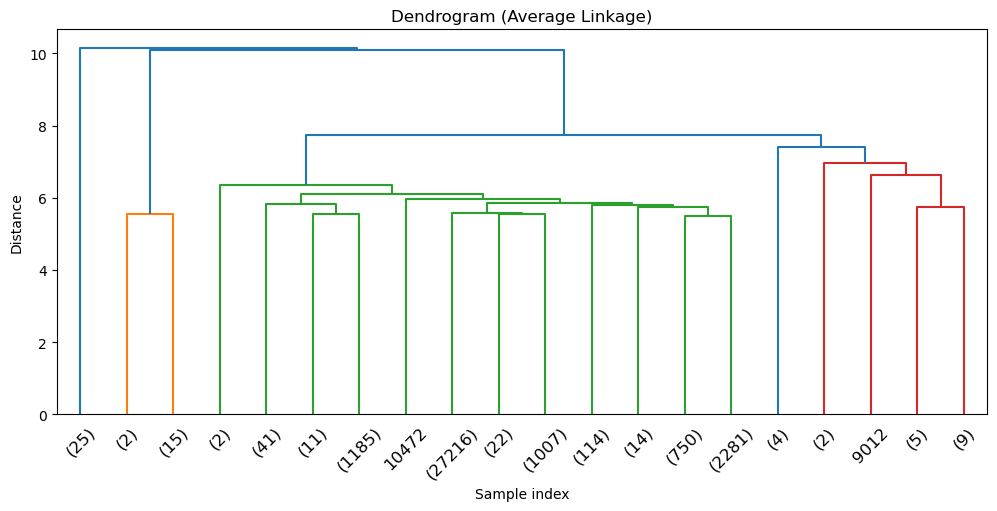

In [46]:
# ── Dendrogram to visualize structure ──────────────────────────────────────
linked = linkage(X_scaled_clean, method='average') # Can be 'ward', 'complete', 'average', 'single'

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Dendrogram (Average Linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

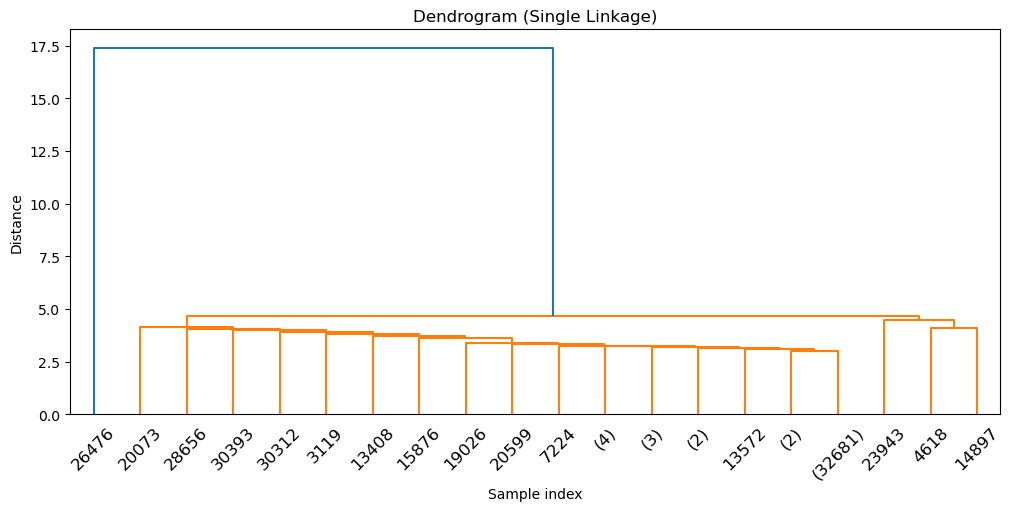

In [47]:
# ── Dendrogram to visualize structure ──────────────────────────────────────
linked_pca = linkage(X_pca_clean, method='single') # Can be 'ward', 'complete', 'average', 'single'

plt.figure(figsize=(12, 5))
dendrogram(linked_pca, truncate_mode='lastp', p=20, leaf_rotation=45)
plt.title('Dendrogram (Single Linkage)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

<p style="color: #25a890; font-size: 0.9em;">Hierarchical Divisive clustering was also considered but excluded due to its high computational cost and lack of native library support.</p>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> DBSCAN</h3>

In [48]:
# ── DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled_clean)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = (dbscan_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_scaled_clean, dbscan_labels)
    print(f"DBSCAN         silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"DBSCAN         clusters={n_clusters}  noise={n_noise}  (tune eps/min_samples)")

DBSCAN         silhouette=-0.118  clusters=4  noise=32682


In [49]:
# ── DBSCAN with PCA ─────────────────────────────────────────────────────────────────
dbscan_pca = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels_pca = dbscan_pca.fit_predict(X_pca_clean)
n_clusters_pca = len(set(dbscan_labels_pca)) - (1 if -1 in dbscan_labels_pca else 0)
n_noise_pca = (dbscan_labels_pca == -1).sum()
if n_clusters_pca >= 2:
    score_pca = silhouette_score(X_pca_clean, dbscan_labels_pca)
    print(f"DBSCAN         silhouette={score_pca:.3f}  clusters={n_clusters_pca}  noise={n_noise_pca}")
else:
    print(f"DBSCAN         clusters={n_clusters_pca}  noise={n_noise_pca}  (tune eps/min_samples)")

DBSCAN         silhouette=-0.248  clusters=37  noise=32356


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> HDBSCAN</h3>

In [50]:
# ── HDBSCAN ────────────────────────────────────────────────────────────────
hdb = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb_labels = hdb.fit_predict(X_scaled_clean)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = (hdb_labels == -1).sum()
if n_clusters >= 2:
    score = silhouette_score(X_scaled_clean, hdb_labels)
    print(f"HDBSCAN        silhouette={score:.3f}  clusters={n_clusters}  noise={n_noise}")
else:
    print(f"HDBSCAN        clusters={n_clusters}  noise={n_noise}  (tune min_cluster_size)")

HDBSCAN        silhouette=0.131  clusters=2  noise=2688


In [51]:
# ── HDBSCAN with PCA ────────────────────────────────────────────────────────────────
hdb_pca = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
hdb_labels_pca = hdb_pca.fit_predict(X_pca_clean)
n_clusters_pca = len(set(hdb_labels_pca)) - (1 if -1 in hdb_labels_pca else 0)
n_noise_pca = (hdb_labels_pca == -1).sum()
if n_clusters_pca >= 2:
    score_pca = silhouette_score(X_pca_clean, hdb_labels_pca)
    print(f"HDBSCAN        silhouette={score_pca:.3f}  clusters={n_clusters_pca}  noise={n_noise_pca}")
else:
    print(f"HDBSCAN        clusters={n_clusters_pca}  noise={n_noise_pca}  (tune min_cluster_size)")

HDBSCAN        silhouette=-0.069  clusters=7  noise=14522


<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Self Organizing Map</h3>

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 2.181526057926645
SOM + KMeans        silhouette=0.100  clusters=5
SOM + Agglomerative silhouette=0.141  clusters=5


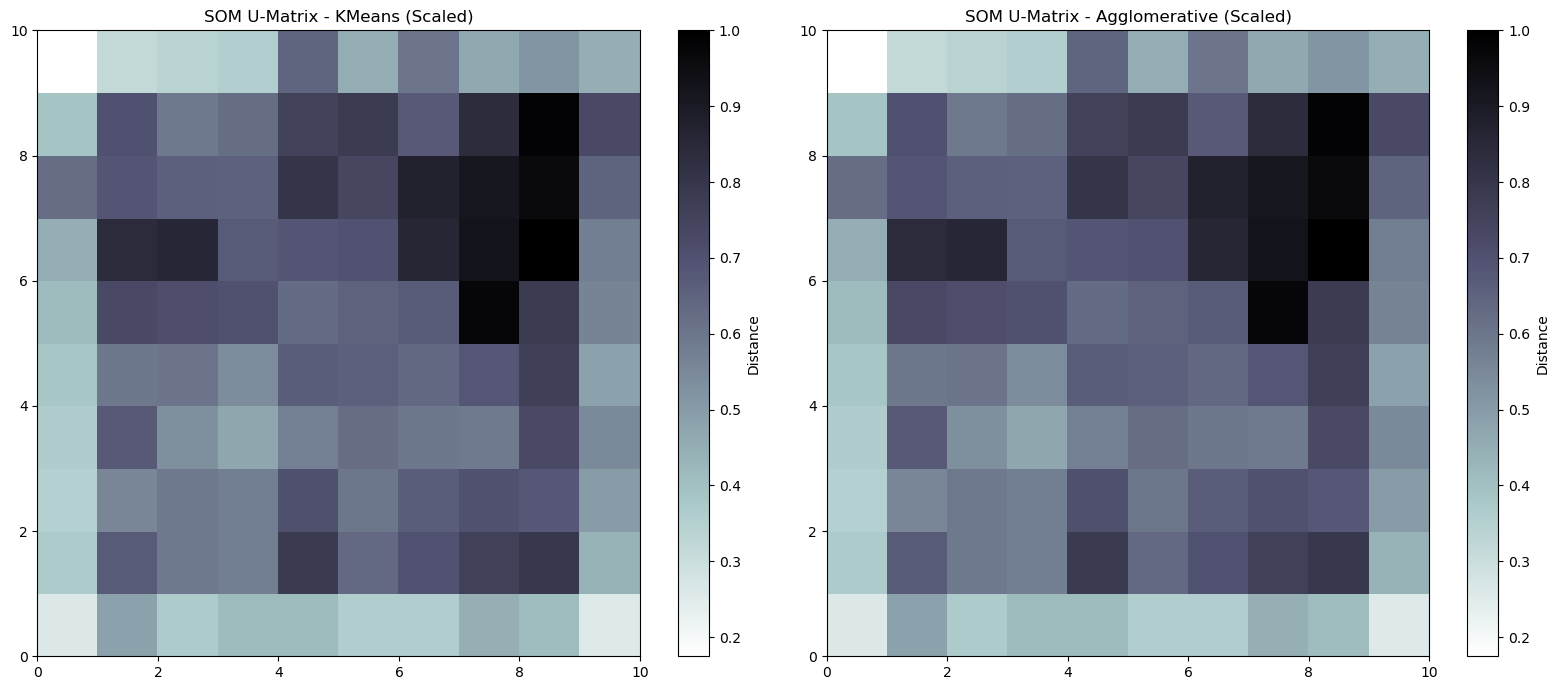

In [52]:
# ── Train SOM on Scaled Data ───────────────────────────────────────
som_x, som_y = 10, 10
som = MiniSom(x=som_x, y=som_y, input_len=X_scaled_clean.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=42)

X_scaled_array = X_scaled_clean.values
som.random_weights_init(X_scaled_array)
som.train(X_scaled_array, num_iteration=10000, verbose=True)

# ── Assign each customer to a neuron ──────────────────────────────────────
winner_coordinates = np.array([som.winner(x) for x in X_scaled_array])
weights = som.get_weights().reshape(-1, X_scaled_array.shape[1])

# ── KMeans on neuron weights ───────────────────────────────────────────────
neuron_labels_km = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(weights)
som_labels = np.array([neuron_labels_km[x * som_y + y] for x, y in winner_coordinates])
score_km = silhouette_score(X_scaled_array, som_labels)
print(f"SOM + KMeans        silhouette={score_km:.3f}  clusters={len(set(som_labels))}")

# ── Agglomerative on neuron weights ───────────────────────────────────────
neuron_labels_agg = AgglomerativeClustering(n_clusters=5, linkage='average').fit_predict(weights)
som_agg_labels = np.array([neuron_labels_agg[x * som_y + y] for x, y in winner_coordinates])
score_agg = silhouette_score(X_scaled_array, som_agg_labels)
print(f"SOM + Agglomerative silhouette={score_agg:.3f}  clusters={len(set(som_agg_labels))}")

# ── U-Matrix side by side ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, title in zip(axes, ['SOM U-Matrix - KMeans (Scaled)', 'SOM U-Matrix - Agglomerative (Scaled)']):
    im = ax.pcolor(som.distance_map().T, cmap='bone_r')
    fig.colorbar(im, ax=ax, label='Distance')
    ax.set_title(title)

plt.tight_layout()
plt.show()

 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 1.987693551489179
SOM + KMeans        silhouette=0.097  clusters=8
SOM + Agglomerative silhouette=0.103  clusters=8


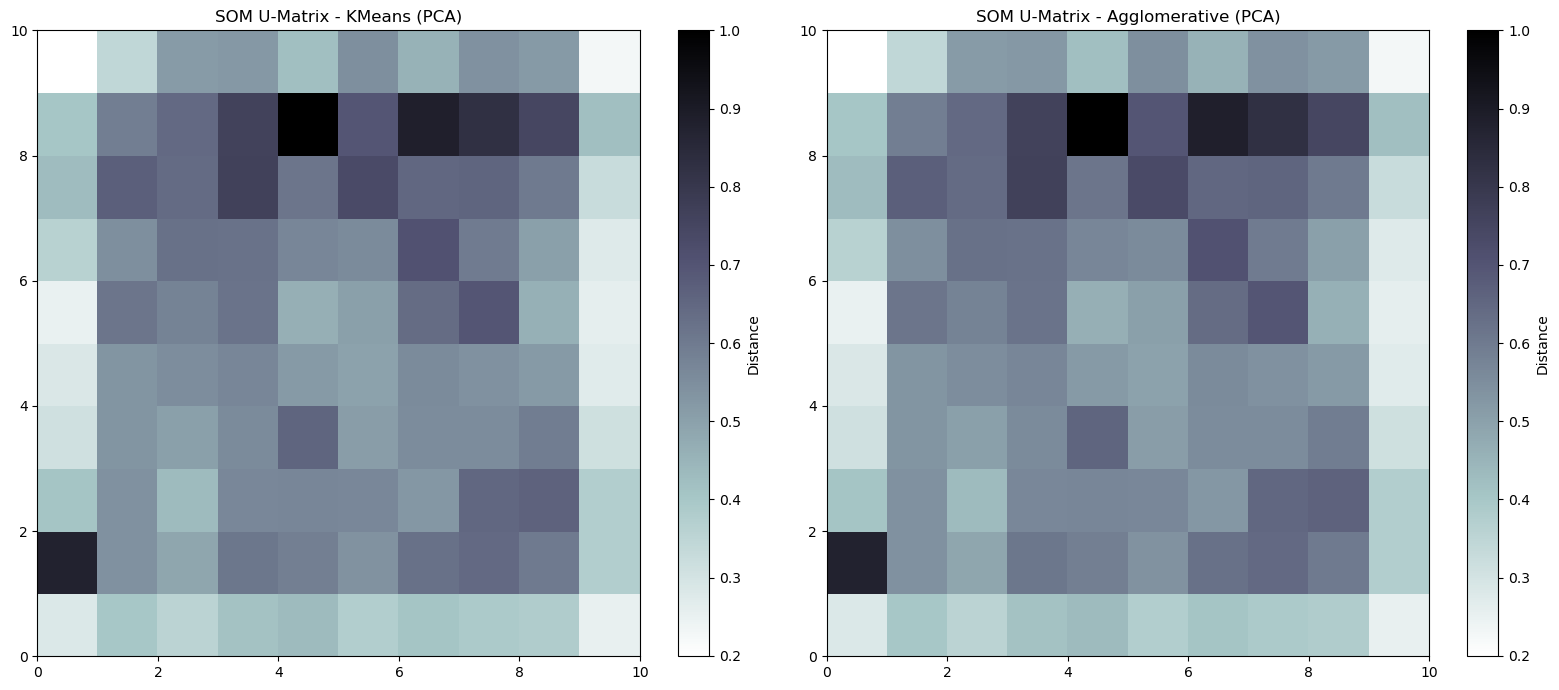

In [53]:
# ── Train SOM on PCA Data ───────────────────────────────────────
som_x, som_y = 10, 10
som = MiniSom(x=som_x, y=som_y, input_len=X_pca_clean.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)

X_pca_array = X_pca_clean.values
som.random_weights_init(X_pca_array)
som.train(X_pca_array, num_iteration=10000, verbose=True)

# ── Assign each customer to a neuron ──────────────────────────────────────
winner_coordinates = np.array([som.winner(x) for x in X_pca_array])
weights = som.get_weights().reshape(-1, X_pca_array.shape[1])

# ── KMeans on neuron weights ───────────────────────────────────────────────
neuron_labels_km = KMeans(n_clusters=8, random_state=42, n_init=10).fit_predict(weights)
som_labels = np.array([neuron_labels_km[x * som_y + y] for x, y in winner_coordinates])
score_km = silhouette_score(X_pca_array, som_labels)
print(f"SOM + KMeans        silhouette={score_km:.3f}  clusters={len(set(som_labels))}")

# ── Agglomerative on neuron weights ───────────────────────────────────────
neuron_labels_agg = AgglomerativeClustering(n_clusters=8, linkage='average').fit_predict(weights)
som_agg_labels = np.array([neuron_labels_agg[x * som_y + y] for x, y in winner_coordinates])
score_agg = silhouette_score(X_pca_array, som_agg_labels)
print(f"SOM + Agglomerative silhouette={score_agg:.3f}  clusters={len(set(som_agg_labels))}")

# ── U-Matrix side by side ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, title in zip(axes, ['SOM U-Matrix - KMeans (PCA)', 'SOM U-Matrix - Agglomerative (PCA)']):
    im = ax.pcolor(som.distance_map().T, cmap='bone_r')
    fig.colorbar(im, ax=ax, label='Distance')
    ax.set_title(title)

plt.tight_layout()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">We applied SOM combined with Agglomerative Clustering using average and single linkage, as it yielded the best silhouette score among the linkage methods tested.</p>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Visualization</h2>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> T-SNE</h3>

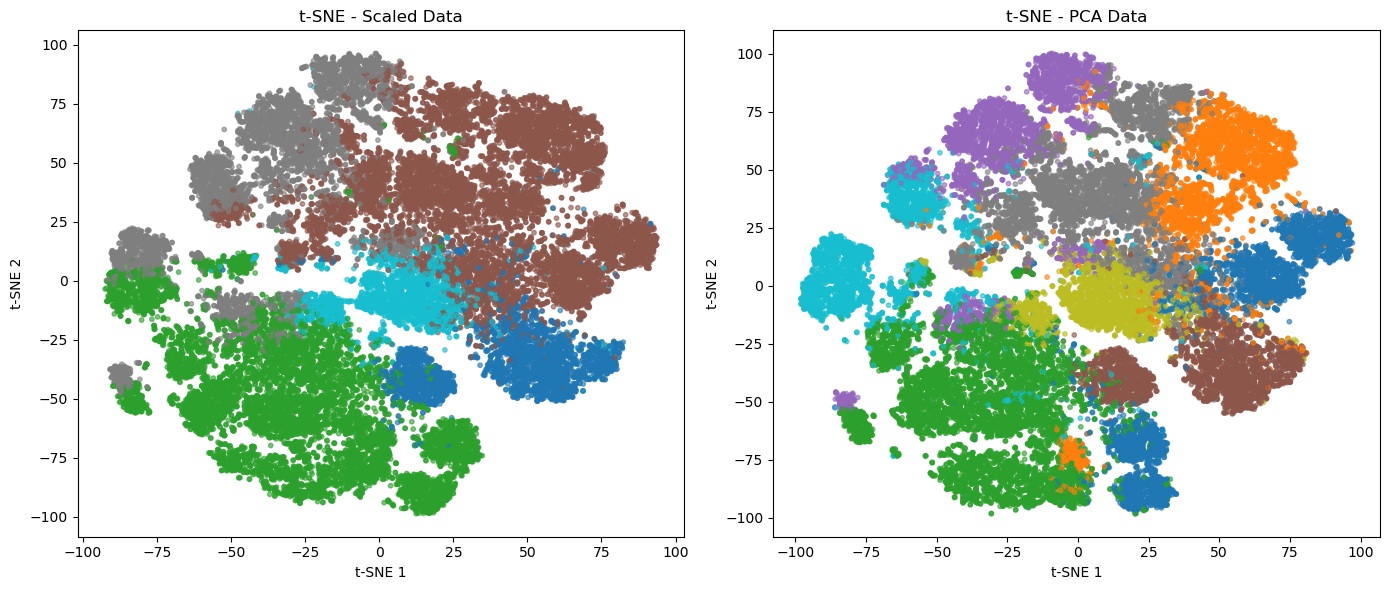

In [54]:
X_tsne_scaled = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled_clean)
X_tsne_pca = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_pca_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne_scaled[:, 0], X_tsne_scaled[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('t-SNE - Scaled Data')

axes[1].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=kmeans_labels_pca, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('t-SNE - PCA Data')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> UMAP</h3>

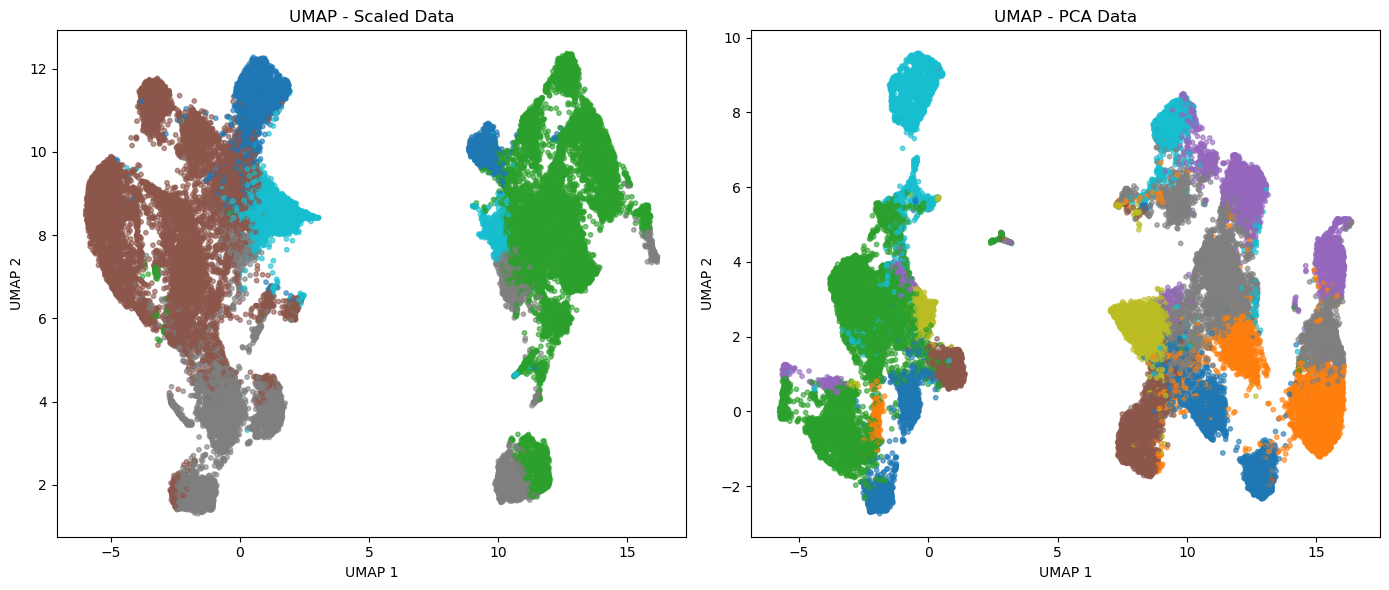

In [55]:
X_umap_scaled = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled_clean)
X_umap_pca = umap.UMAP(n_components=2, random_state=42).fit_transform(X_pca_clean)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_umap_scaled[:, 0], X_umap_scaled[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('UMAP - Scaled Data')

axes[1].scatter(X_umap_pca[:, 0], X_umap_pca[:, 1], c=kmeans_labels_pca, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('UMAP - PCA Data')

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> PCA Visualization</h3>

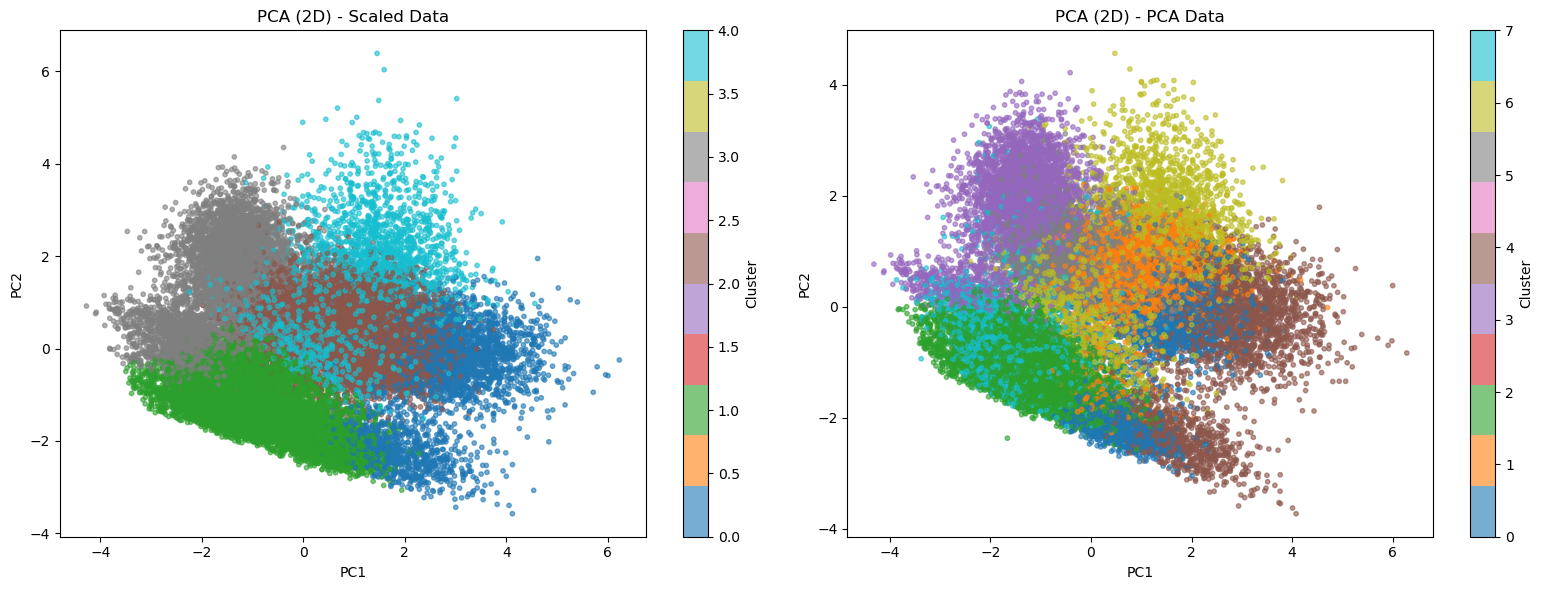

In [56]:
X_scaled_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled_clean)
X_pca_2d = PCA(n_components=2, random_state=42).fit_transform(X_pca_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_scaled_2d[:, 0], X_scaled_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, s=10)
axes[0].set_title('PCA (2D) - Scaled Data')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
fig.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels_pca, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title('PCA (2D) - PCA Data')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
fig.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Clusters</h2>

<p style="color: #25a890; font-size: 0.9em;">
    Several clustering algorithms were tested on both scaled and PCA-preprocessed data,
    compared using the silhouette score as the primary metric.
    <br><br>
    <strong>K-Means</strong> achieved the highest reliable score on scaled data (0.147) with
    5 clusters, supported by the silhouette peak at k=5 observed during hyperparameter tuning
    on both the elbow and silhouette curves. On PCA data, k=8 yielded a marginally higher score
    (0.148), but the added complexity of 8 clusters was not justified by such a negligible gain.
    <br><br>
    <strong>Hierarchical (Agglomerative)</strong> clustering was tested with four linkage methods
    on both datasets. On scaled data: ward (0.116), complete (0.112), average (0.339), single
    (0.319). On PCA data: ward (0.114), complete (0.123), average (0.259), single (0.647).
    While average and single linkage produced high scores, these are misleading — both methods
    tend to form one dominant cluster with minimal satellite groups, artificially inflating the
    silhouette metric. Ward and complete linkage gave more balanced partitions but scored below
    K-Means on both datasets.
    <br><br>
    <strong>DBSCAN</strong> performed poorly on both inputs: silhouette of -0.118 with 4 clusters
    and 32,682 noise points on scaled data, and -0.248 with 37 clusters and 32,356 noise points
    on PCA data — confirming it is ill-suited for this dataset's density structure regardless of
    preprocessing.
    <br><br>
    <strong>HDBSCAN</strong> found only 2 clusters (silhouette 0.131) on scaled data and 7
    clusters (silhouette -0.069) on PCA data, neither of which is sufficient or stable enough
    for meaningful customer segmentation.
    <br><br>
    <strong>SOM</strong> combined with KMeans and Agglomerative clustering produced scores of
    0.093/0.136 on scaled data and 0.097/0.095 on PCA data — comparable but without improvement
    over plain K-Means in either case.
    <br><br>
    <strong>Why PCA preprocessing was not worth it:</strong> Across every algorithm tested,
    PCA preprocessing either matched or degraded performance compared to the scaled data baseline.
    K-Means gained only 0.001 in silhouette while requiring 3 additional clusters. DBSCAN became
    worse (−0.248 vs −0.118) and produced 37 noisy clusters. HDBSCAN went from a modest 2-cluster
    solution to a negative score. SOM results were essentially identical. The t-SNE and UMAP
    visualisations further confirm this: the scaled data projections show cleaner, more compact
    and well-separated cluster boundaries, while the PCA-preprocessed projections show more
    fragmented and overlapping structures. PCA reduces dimensionality by maximising variance, but
    in doing so it discards information that may be important for separating customer segments,
    ultimately adding complexity without any meaningful gain in clustering quality.
    <br><br>
    Overall, <strong>K-Means with 5 clusters on scaled data</strong> was selected as the best
    balance between interpretability and clustering quality, consistent with both the elbow method,
    silhouette analysis, and the visual evidence from t-SNE and UMAP projections.
</p>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Clusters Information</h3>

In [57]:
for cluster, count in sorted(Counter(kmeans_labels).items()):
    print(f"Cluster {cluster} has {count} rows")

Cluster 0 has 3207 rows
Cluster 1 has 9997 rows
Cluster 2 has 11246 rows
Cluster 3 has 6029 rows
Cluster 4 has 2228 rows


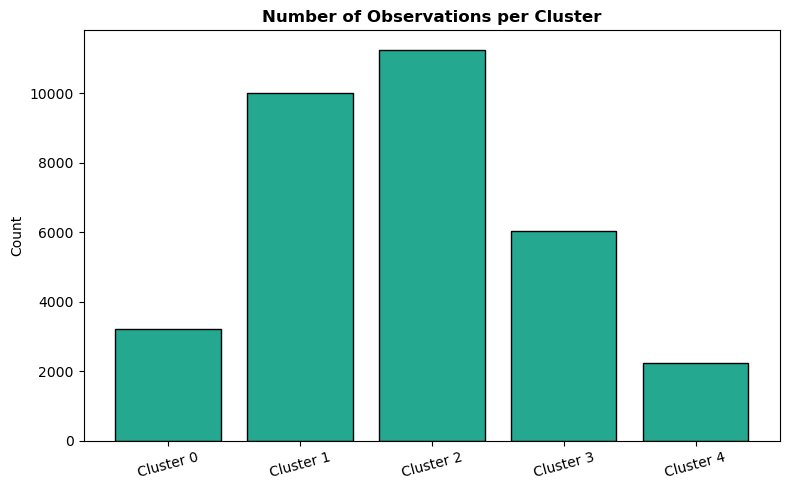

In [58]:
# Bar chart of cluster sizes
counts = dict(sorted(Counter(kmeans_labels).items()))

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color='#25a890', edgecolor='black')
plt.xticks(ticks=range(5), labels=[f"Cluster {i}" for i in range(5)], rotation=15)
plt.title('Number of Observations per Cluster', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [59]:
cust_info=pd.read_csv('cust_info_engineered.csv')
cust_info=cust_info.set_index('customer_id')
cluster_features = ['age',
    'year_first_transaction',
    'progenitores',
    'spend_per_store',
    'fresh_food_ratio',
    'lifetime_spend_groceries',
    'lifetime_spend_alcohol_drinks',
    'lifetime_spend_nonalcohol_drinks',
    'lifetime_spend_hygiene',
    'lifetime_spend_petfood',
    'lifetime_total_distinct_products',
    'percentage_of_products_bought_promotion',
    'distinct_stores_visited',
    'promotion_guy',
    'healthy_guy',
    'tech_enthusiast',
    'has_loyalty_card',
    'loyal_long_timer']

In [60]:
all_labels = np.empty(len(X_scaled), dtype=int)
all_labels[outlier_mask] = kmeans_labels
all_labels[~outlier_mask] = outlier_labels

In [61]:
cluster_means = cust_info[cluster_features].copy().reset_index(drop=True)
cluster_means['cluster'] = all_labels
cluster_means.groupby('cluster')[cluster_features].mean().round(2).head(20)

,age,year_first_transaction,progenitores,spend_per_store,fresh_food_ratio,lifetime_spend_groceries,lifetime_spend_alcohol_drinks,lifetime_spend_nonalcohol_drinks,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,distinct_stores_visited,promotion_guy,healthy_guy,tech_enthusiast,has_loyalty_card,loyal_long_timer
cluster,,,,,,,,,,,,,,,,,,
0,56.81,2013.29,5.95,11578.35,0.21,25617.75,1454.81,849.45,935.64,362.83,311.94,0.21,3.19,5295.22,0.13,0.34,0.71,9.07
1,54.31,2016.07,1.57,5805.69,0.51,13128.75,604.18,440.39,787.82,328.83,134.41,0.24,3.13,3059.15,0.37,0.87,0.01,0.00
2,57.78,2014.56,1.62,7031.41,0.49,14637.39,477.51,472.37,962.45,359.02,137.02,0.19,2.88,2616.74,0.36,0.90,1.00,11.44
3,46.66,2017.00,1.45,3925.76,0.28,10876.52,440.66,205.21,418.08,281.43,68.86,0.71,3.48,7728.07,0.14,0.27,0.73,6.83
4,57.81,2013.25,1.86,12369.36,0.07,39814.40,696.78,669.95,1141.66,360.39,252.57,0.62,3.87,23410.06,0.04,0.11,0.79,10.30


<p style="color: #25a890; font-size: 0.9em;">Using the cluster profiles obtained above, we identified the following segments:</p>
<p style="color: #25a890; font-size: 0.9em;">
    0 - Big Family Shopper <br>
    1 - New Customers + Tech Enthusiast <br>
    2 - Most Loyal <br>
    3 - Bargain Hunter <br>
    4 - Biggest Buyers (with Promotion)
</p>

<h3 style="color: #25a890; font-size: 1.3em; font-weight: 600; margin-bottom: 10px;"> Clusters Information Visualization</h3>

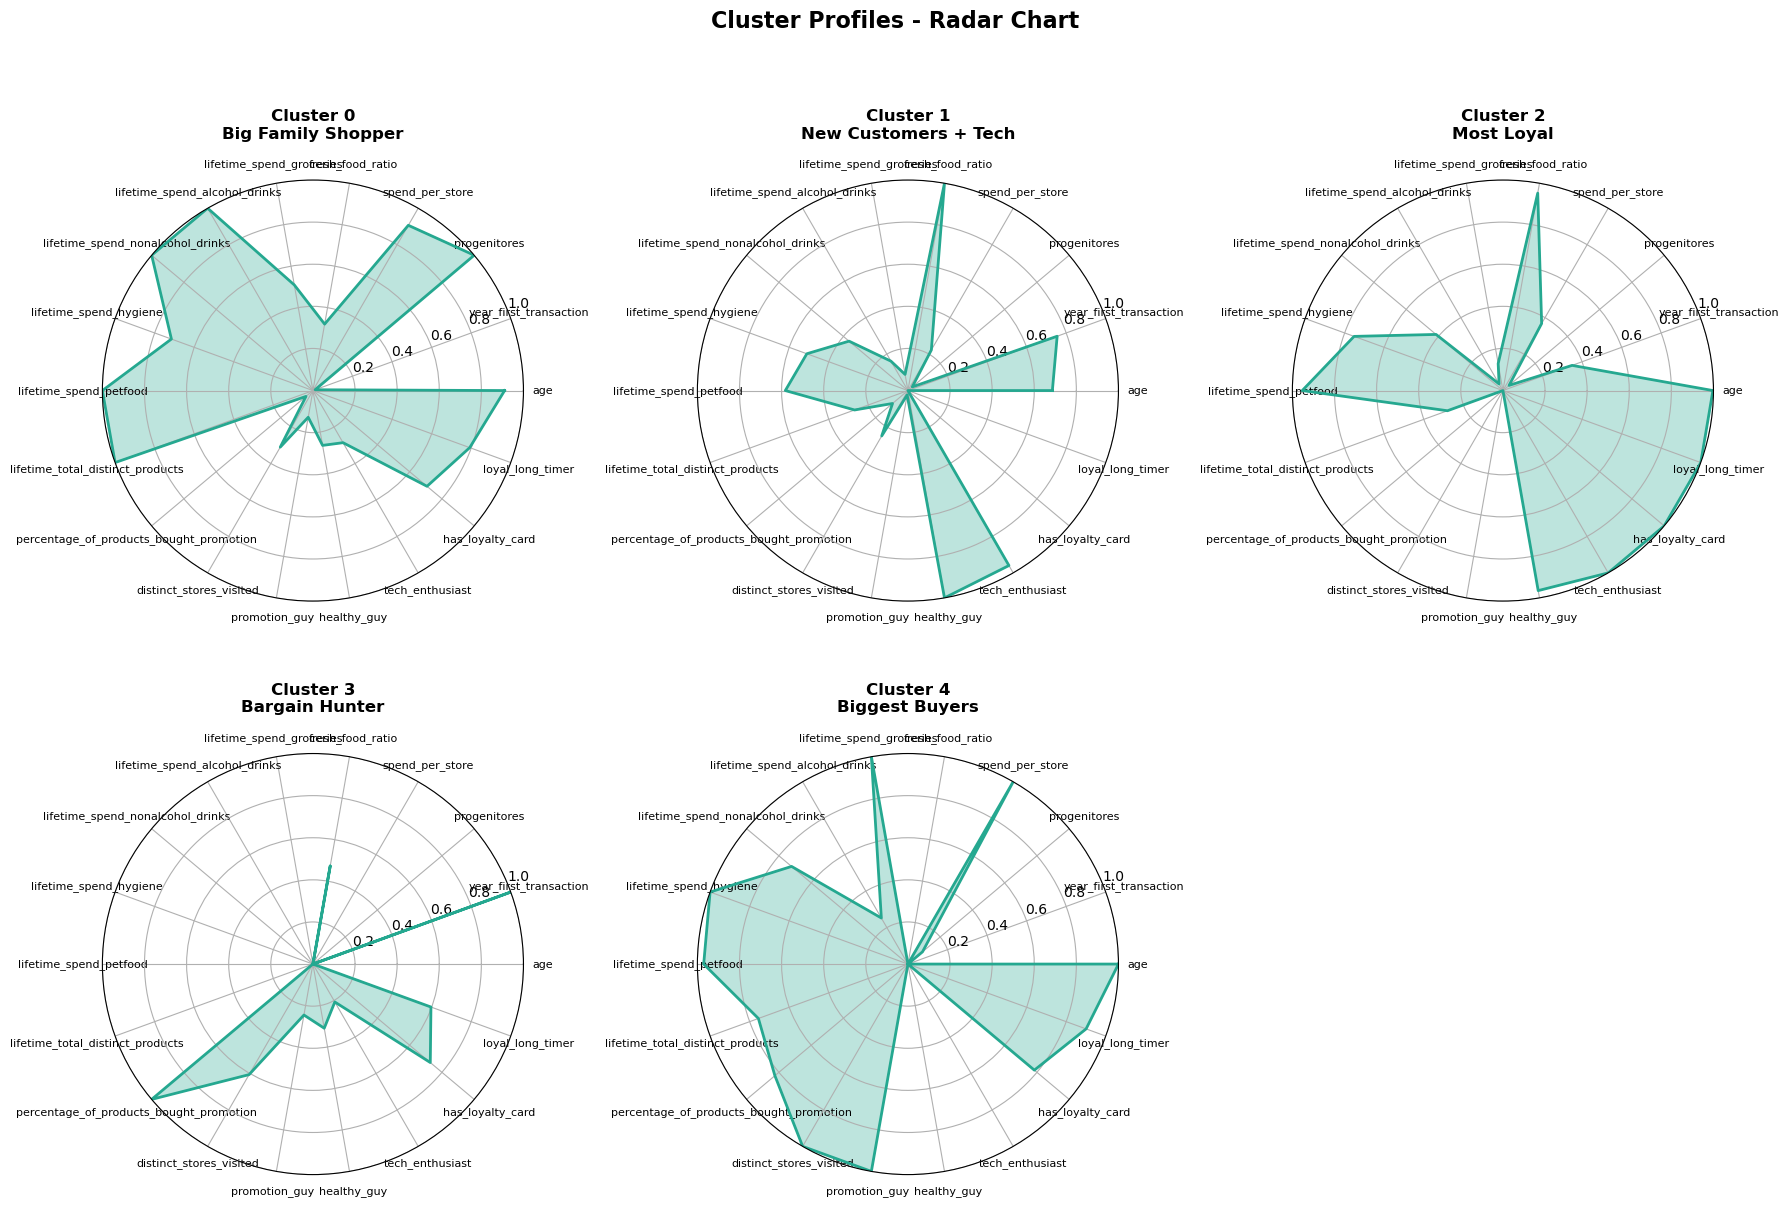

In [62]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.pyplot as plt
import numpy as np

# Get cluster means normalized between 0 and 1 for radar
cluster_summary = cluster_means.groupby('cluster')[cluster_features].mean()
cluster_norm = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())

# Radar setup
categories = cluster_features
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

cluster_names = {
    0: "Big Family Shopper",
    1: "New Customers + Tech",
    2: "Most Loyal",
    3: "Bargain Hunter",
    4: "Biggest Buyers"
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    values = cluster_norm.loc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, linestyle='solid', color='#25a890')
    ax.fill(angles, values, alpha=0.3, color='#25a890')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=8)
    ax.set_title(f"Cluster {i}\n{cluster_names[i]}", size=12, fontweight='bold', pad=15)
    ax.set_ylim(0, 1)

axes[-1].set_visible(False)  # hide the empty 6th subplot

plt.suptitle('Cluster Profiles - Radar Chart', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">Each axis is normalized between 0 and 1, where 1 indicates the highest and 0 the lowest value for that variable relative to all other clusters.</p>

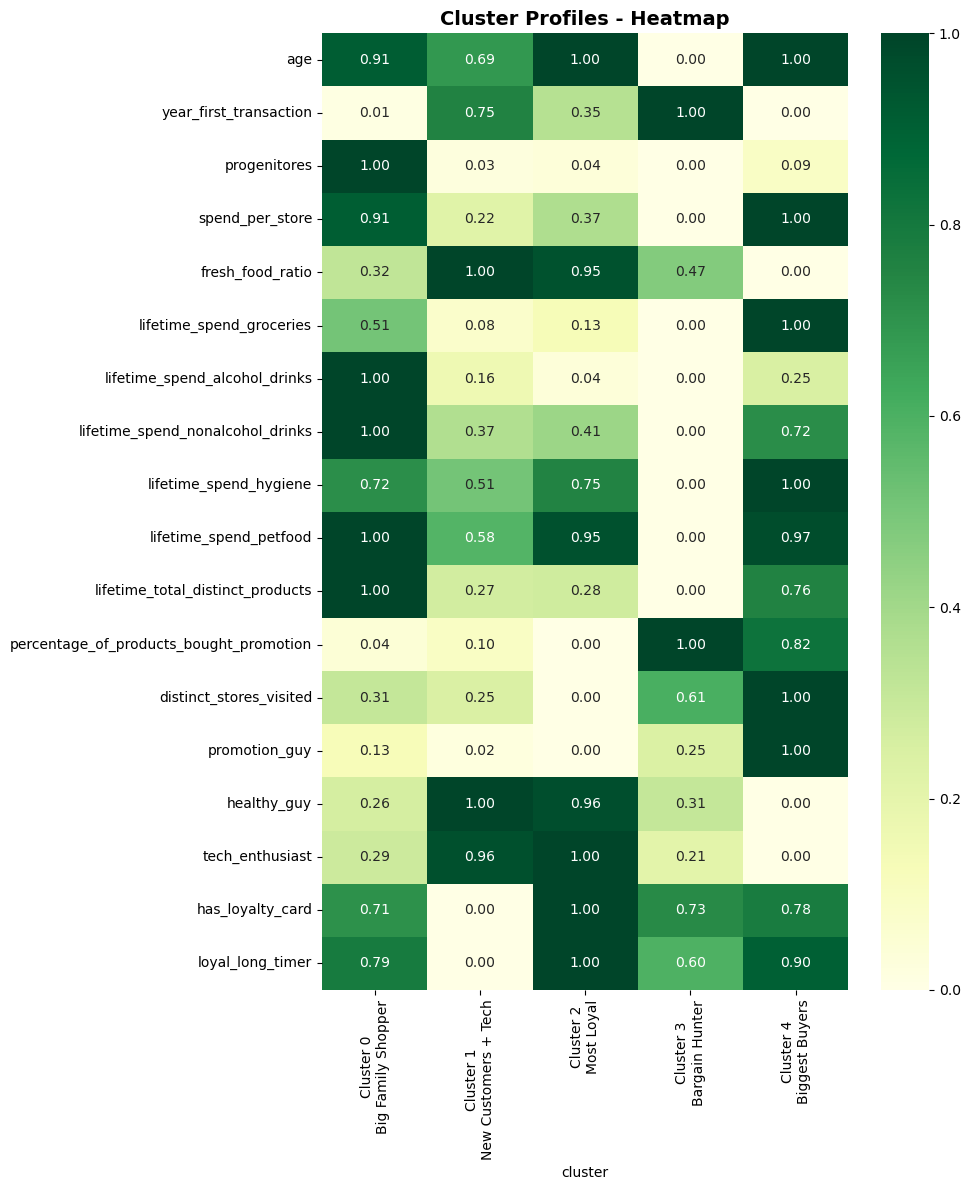

In [63]:
import seaborn as sns

plt.figure(figsize=(10, 12))
sns.heatmap(cluster_norm.T, annot=True, fmt='.2f', cmap='YlGn', xticklabels=[f"Cluster {i}\n{cluster_names[i]}" for i in range(5)], yticklabels=cluster_features)
plt.title('Cluster Profiles - Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">Values are normalized between 0 and 1, where 1 indicates the highest and 0 the lowest value for that variable relative to all other clusters.</p>

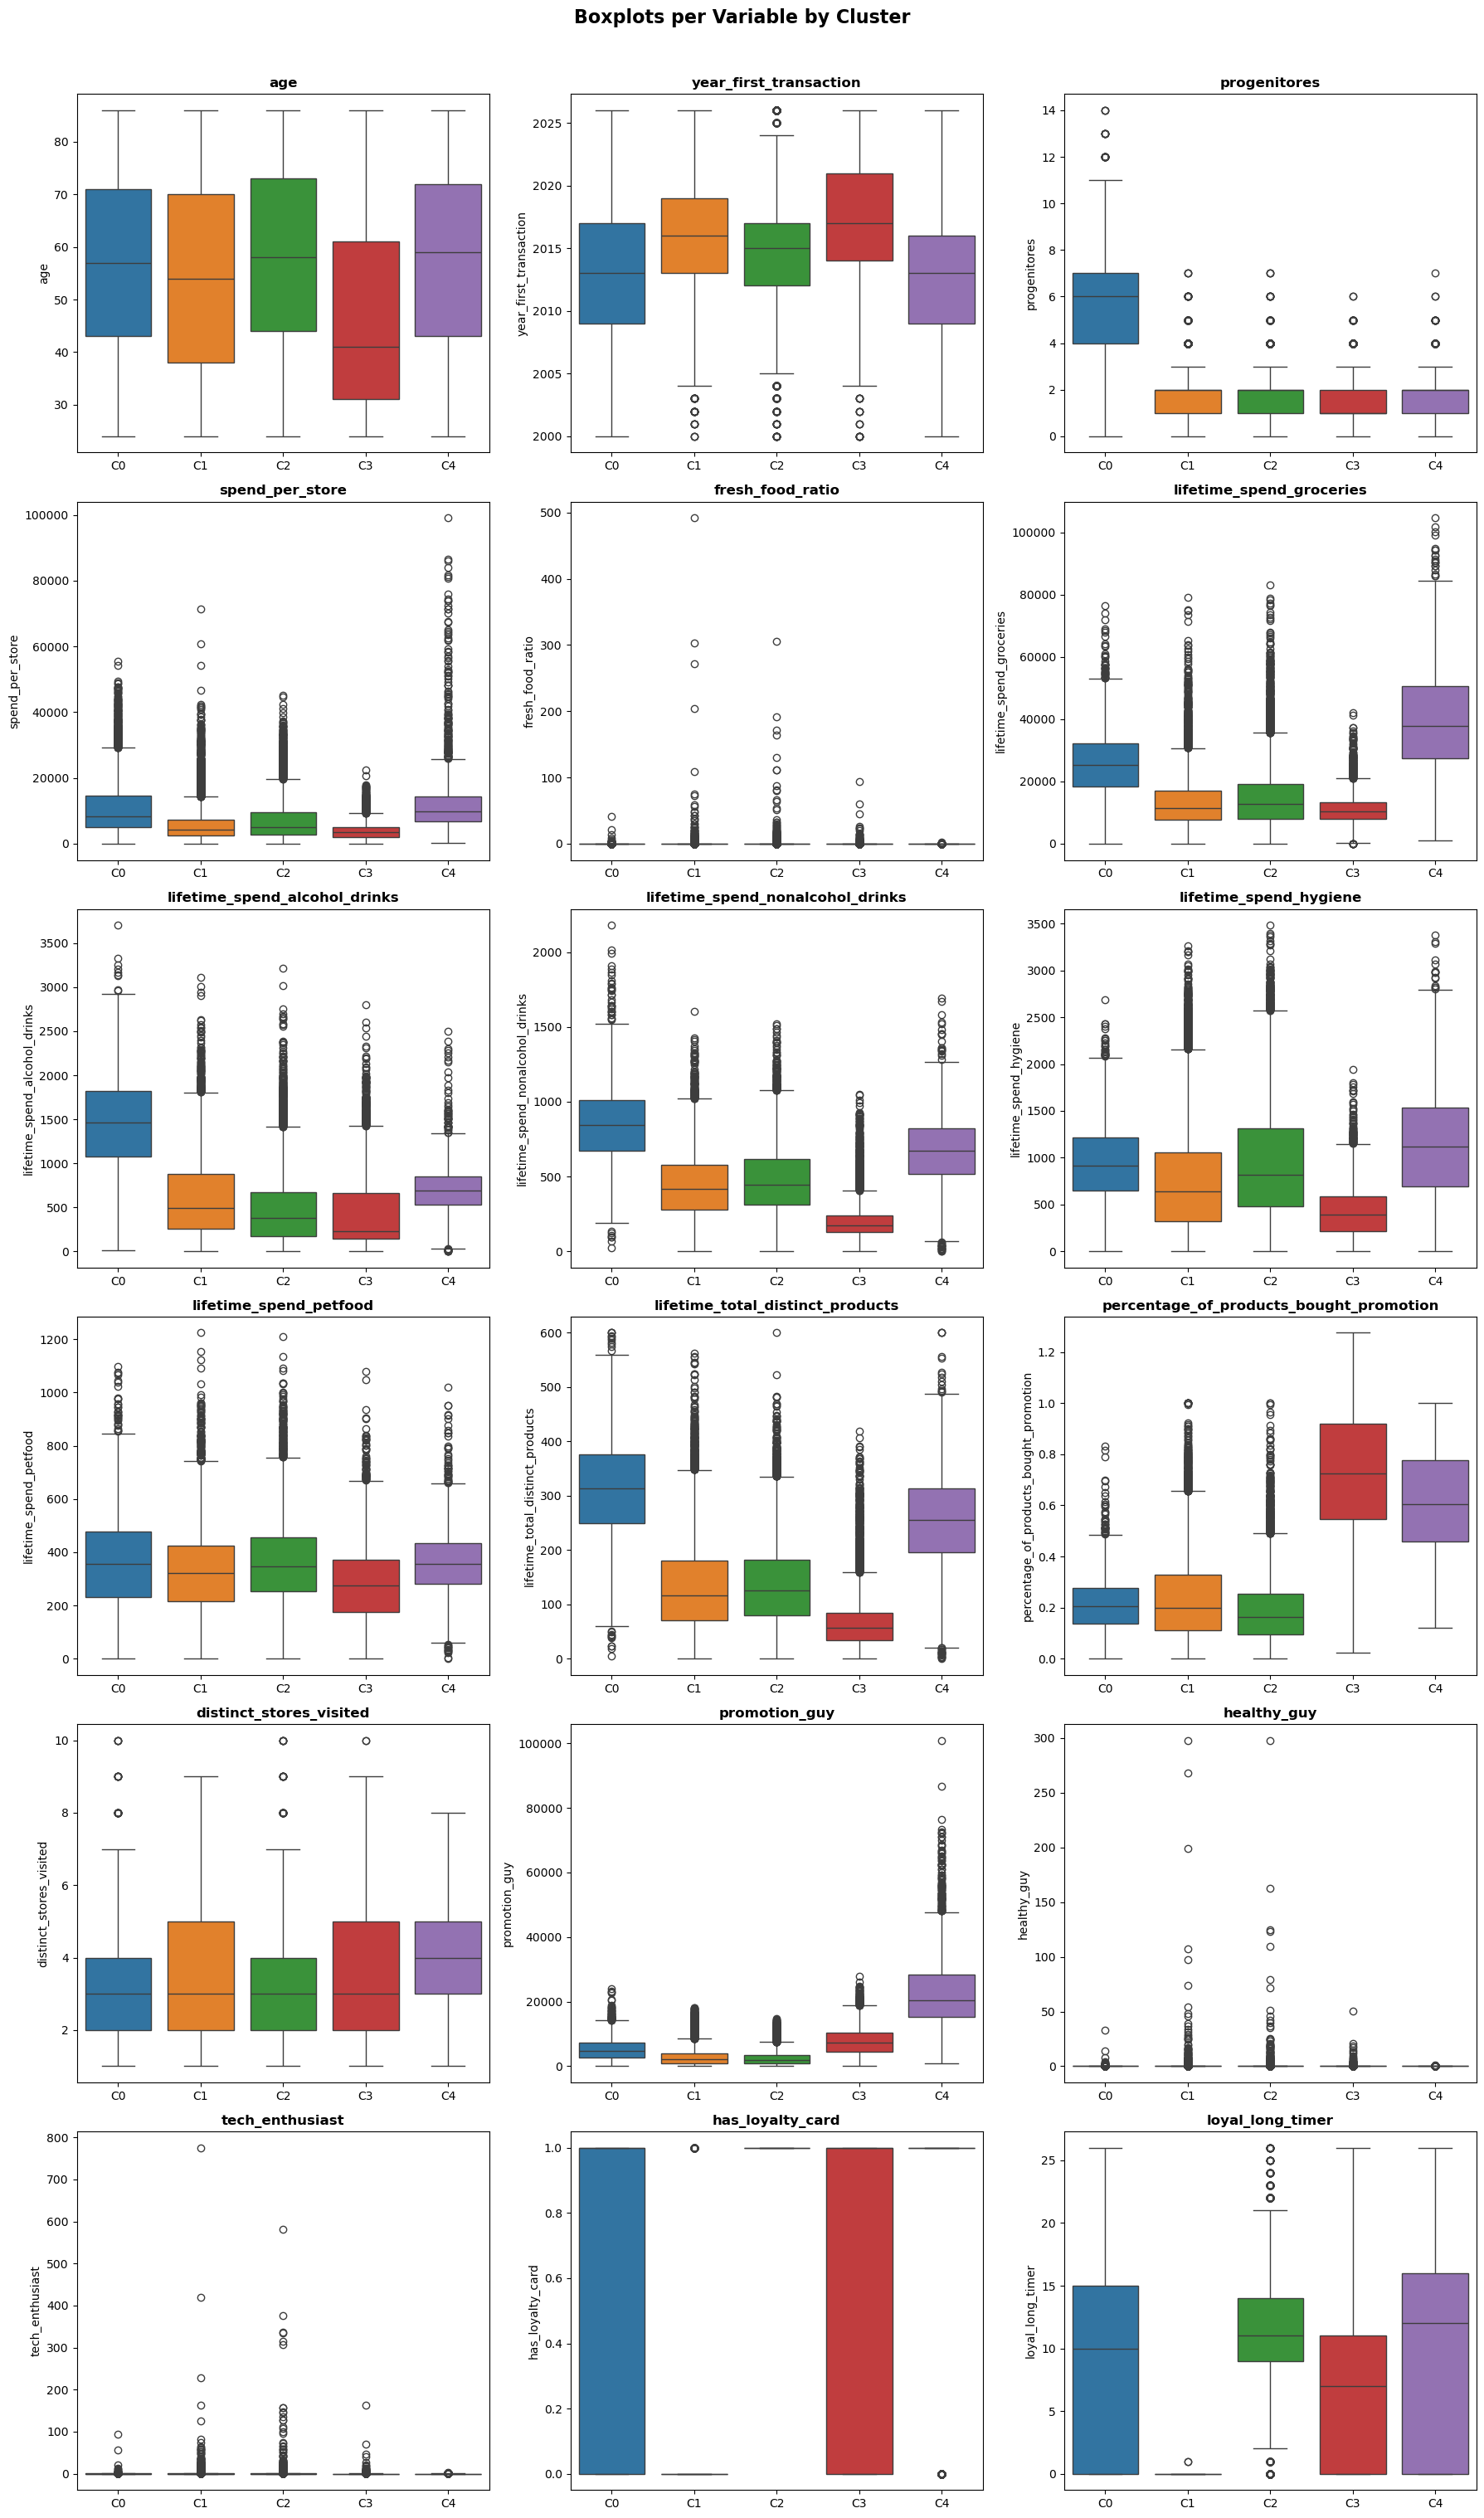

In [64]:
fig, axes = plt.subplots(6, 3, figsize=(18, 30))
axes = axes.flatten()

for i, var in enumerate(cluster_features):
    sns.boxplot(data=cluster_means, x='cluster', y=var, palette='tab10', ax=axes[i])
    axes[i].set_title(var, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels([f"C{i}" for i in range(5)])

# Hide empty subplots
for j in range(len(cluster_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots per Variable by Cluster', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<p style="color: #25a890; font-size: 0.9em;">
    Each boxplot shows the distribution of a variable across clusters, where each data point 
    represents the mean value for one customer within that cluster.
</p>

<h2 style="color: #25a890; margin-bottom: 5px; font-weight: 700;"> Export</h2>

In [65]:
result = pd.DataFrame({'customer_id': X_scaled.index, 'cluster': all_labels})
result.to_csv('cluster_assignments.csv', index=False)

In [66]:
print(f"Total customers in original data: {len(X_scaled)}")
print(f"Total customers in output: {len(result)}")


Total customers in original data: 33038
Total customers in output: 33038
